In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

# Laoding Dataset

In [3]:
X, y = make_classification(n_samples=300, n_features=2, n_informative=1, n_redundant=0,
                          n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False,class_sep=10)

In [4]:
df = pd.DataFrame(data=X, columns=['X1','X2'])
df['Y'] = y

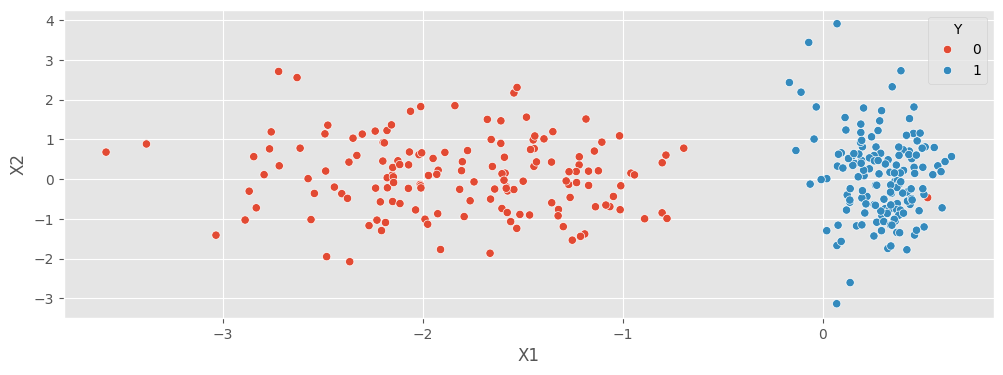

In [5]:
plt.figure(figsize=(12,4))
sns.scatterplot(data=df,x='X1',y='X2',hue='Y')
plt.show()

# Logistic Regression Using sklearn

In [6]:
lr = LogisticRegression(penalty=None,solver='sag',max_iter=10000)
lr.fit(df[['X1','X2']],df['Y'])
lr.coef_, lr.intercept_

(array([[7.79864026, 0.44000828]]), array([3.14300262]))

In [7]:
lr_X_1 = -(lr.intercept_ + lr.coef_[0][1]*df['X2']) / lr.coef_[0][0]

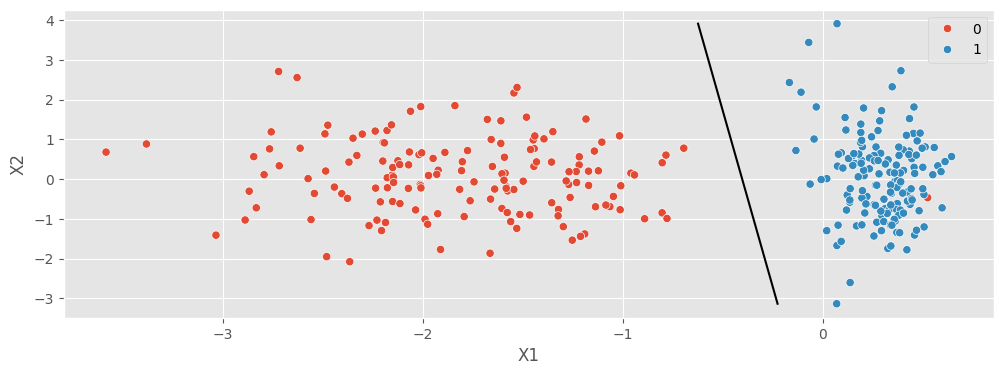

In [8]:
plt.figure(figsize=(12,4))
sns.scatterplot(data=df,x='X1',y='X2',hue='Y')
sns.lineplot(x=lr_X_1,y=df['X2'],color=(0,0,0,1))
plt.show()

# Perceptron Trick Using Step Function

In [9]:
class MyPerceptron:
    def __init__(self, epochs=1000, lr=0.01):
        self.epochs = epochs
        self.lr = lr
        self.Line = None

    def fit(self,X,y):
        X = np.insert(X,0,1,axis=1)
        self.Line = np.array(np.ones(X.shape[1])).reshape(X.shape[1],1)
        y = np.array(y)
        for _ in range(self.epochs):
            idx = np.random.choice(range(0,X.shape[0]),size=1,replace=False)
            y_hat = X[idx].dot(self.Line)
            y_hat = self.step(X[idx].dot(self.Line))
            self.Line = self.Line + (self.lr * (y[idx] - y_hat)) * X[idx].T
        print(self.Line)

    def step(self, val):
        return 1 if val>0 else 0

In [10]:
MyPcpt = MyPerceptron(epochs=10000, lr=.5)
MyPcpt.fit(df[['X1','X2']],df[['Y']])

[[ 1.        ]
 [ 1.67394589]
 [-0.23699491]]


In [11]:
mp_X_1 = -(MyPcpt.Line[0] + MyPcpt.Line[2]*df['X2']) / MyPcpt.Line[1]

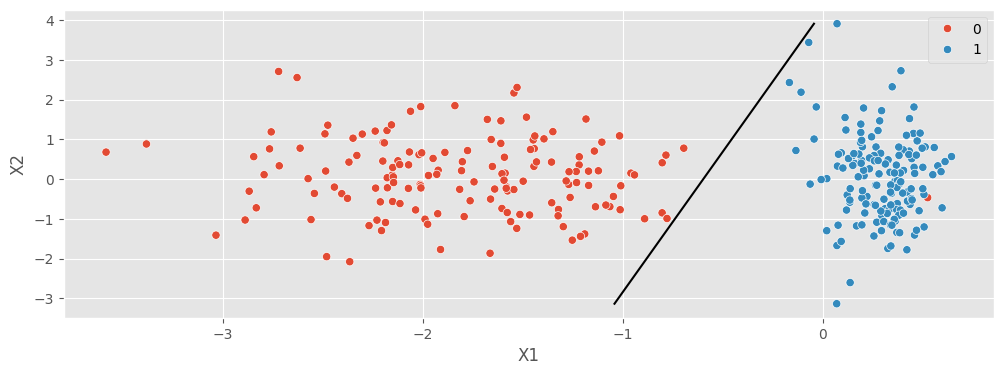

In [12]:
plt.figure(figsize=(12,4))
sns.scatterplot(data=df,x='X1',y='X2',hue='Y')
sns.lineplot(x=mp_X_1,y=df['X2'],color=(0,0,0,1))
plt.show()

# Perceptron Trick Using Sigmoid Function

In [13]:
class MyPerceptron_sigmoid:
    def __init__(self, epochs=1000, lr=0.01):
        self.epochs = epochs
        self.lr = lr
        self.Line = None

    def fit(self,X,y):
        X = np.insert(X,0,1,axis=1)
        self.Line = np.array(np.ones(X.shape[1])).reshape(X.shape[1],1)
        y = np.array(y)
        for _ in range(self.epochs):
            idx = np.random.randint(0,X.shape[0],size=1)
            y_hat = self.sigmoid(X[idx].dot(self.Line))
            self.Line = self.Line + (self.lr * (y[idx] - y_hat)) * X[idx].T
        print(self.Line)

    def sigmoid(self, val):
        return 1/(1+np.exp(-val))

In [14]:
MyPcpt_sigmoid = MyPerceptron_sigmoid(epochs=10000, lr=.5)
MyPcpt_sigmoid.fit(df[['X1','X2']],df[['Y']])

[[3.78274097]
 [7.92011652]
 [0.37746307]]


In [15]:
mps_X_1 = -(MyPcpt_sigmoid.Line[0] + MyPcpt_sigmoid.Line[2]*df['X2']) / MyPcpt_sigmoid.Line[1]

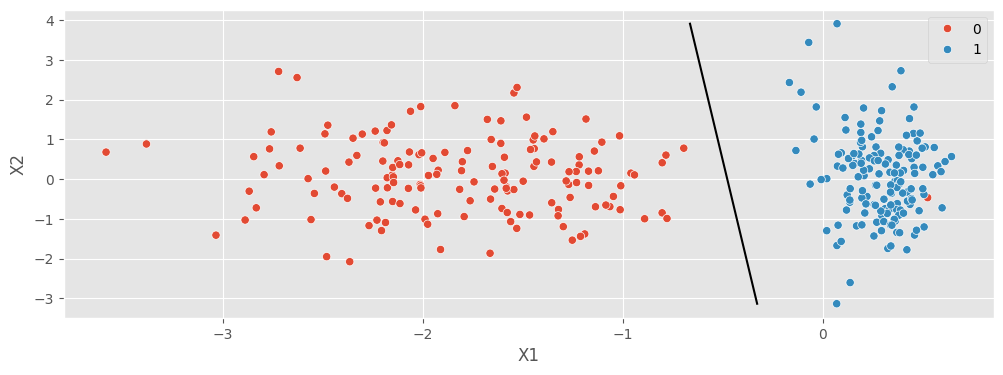

In [16]:
plt.figure(figsize=(12,4))
sns.scatterplot(data=df,x='X1',y='X2',hue='Y')
sns.lineplot(x=mps_X_1,y=df['X2'],color=(0,0,0,1))
plt.show()

# Perceptron Trick Using Sigmoid Function (Gradient Descent)

In [17]:
class MyPerceptron_sigmoid_GD:
    def __init__(self, epochs=1000, lr=0.01):
        self.epochs = epochs
        self.lr = lr
        self.Line = None

    def fit(self,X,y):
        X = np.insert(X,0,1,axis=1)
        self.Line = np.array(np.ones(X.shape[1])).reshape(X.shape[1],1)
        y = np.array(y)
        for _ in range(self.epochs):
            y_hat = self.sigmoid(np.dot(X,self.Line))
            self.Line = self.Line + self.lr * (X.T.dot(y - y_hat) / X.shape[0]) 
        print(self.Line)

    def sigmoid(self, val):
        return 1/(1+np.exp(-val))

In [18]:
MyPcpt_sigmoid_GD = MyPerceptron_sigmoid_GD(epochs=10000, lr=.5)
MyPcpt_sigmoid_GD.fit(X=df[['X1','X2']],y=df[['Y']])

[[3.14307942]
 [7.79940321]
 [0.4400718 ]]


In [19]:
mps_gd_X_1 = -(MyPcpt_sigmoid_GD.Line[0] + MyPcpt_sigmoid_GD.Line[2]*df['X2']) / MyPcpt_sigmoid_GD.Line[1]

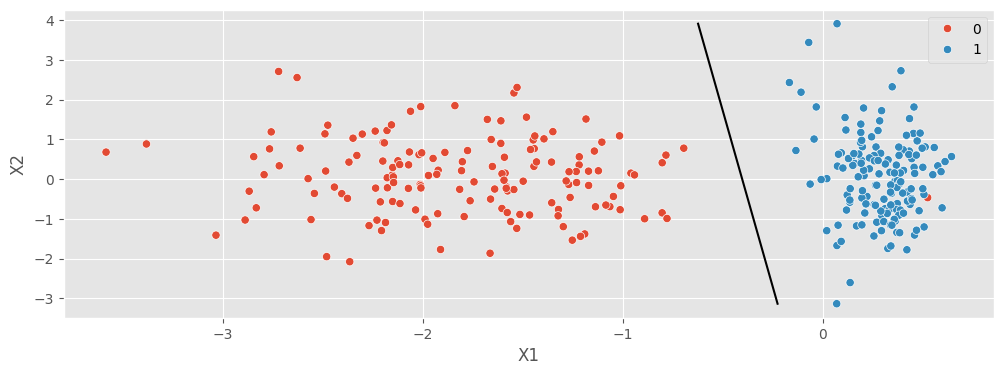

In [20]:
plt.figure(figsize=(12,4))
sns.scatterplot(data=df,x='X1',y='X2',hue='Y')
sns.lineplot(x=mps_gd_X_1,y=df['X2'], color=(0,0,0,1))
plt.show()

# Performance Comparison Of All The Models

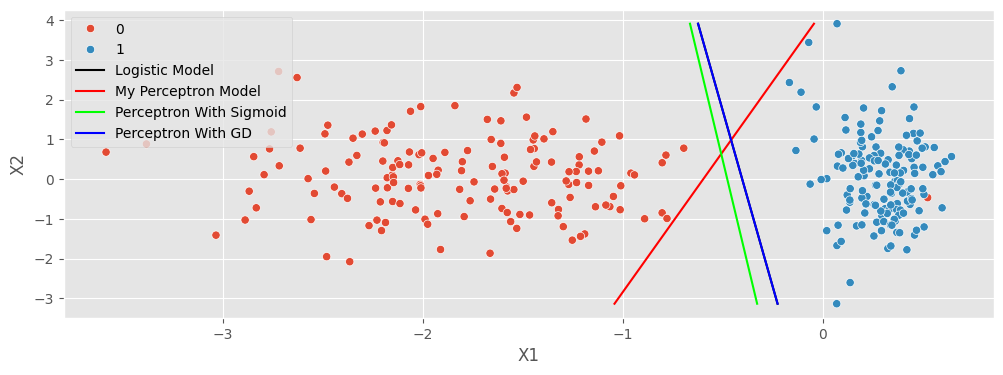

In [21]:
plt.figure(figsize=(12,4))
sns.scatterplot(data=df,x='X1',y='X2',hue='Y')
sns.lineplot(x=lr_X_1,y=df['X2'],color=(0,0,0,1), label='Logistic Model')
sns.lineplot(x=mp_X_1,y=df['X2'],color=(1,0,0,1), label='My Perceptron Model')
sns.lineplot(x=mps_X_1,y=df['X2'],color=(0,1,0,1), label='Perceptron With Sigmoid')
sns.lineplot(x=mps_gd_X_1,y=df['X2'], color=(0,0,1,1), label='Perceptron With GD')
plt.show()